# Argon density from MD: `xnn` vs the original CACE

The end goal of an interatomic potential is *simulation*, so the sharpest test is a
thermodynamic observable. This notebook trains CACE on the Argon data and runs
**NPT molecular dynamics** at 85 K / 1 bar with **both** codes (the paper
validates CACE stability the same way, with MD of water up to 2000 K):

* **track (a), same potential**: the trained original-CACE weights are copied into
  `xnn`; the two MD engines must produce the *same density*.
* **track (b), independently trained models**: train each code separately; densities
  should agree within thermal fluctuations, near the experimental liquid-Ar value
  (~1.41 g/cm³).

Same protocol as `examples/gnn/{mace,nequip,allegro}/03_*`.

## 0. Setup: train `float32`, run MD `float64`

In [1]:
# silence the expected warnings
import logging, warnings
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning,
                        message="You are using `torch.load` with `weights_only=False`")

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import ase.io
import ase.units as u

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CUTOFF, SPECIES = 6.0, [18]
DATA = "../../../datasets/argon_md"
import xnn, cace
print("xnn:", xnn.__version__, "| cace (original): 0.1.0 | device:", DEVICE)

xnn: 0.1.0 | cace (original): 0.1.0 | device: cuda


## 1. Load data and build both data pipelines

In [2]:
from ase import Atoms
def _to_atoms(s):  # rebuild an ASE Atoms for the upstream (CACE) side
    a = Atoms(numbers=s["atomic_numbers"], positions=s["pos"],
              cell=s["cell"], pbc=[True, True, True])
    a.info["REF_energy"] = float(s["energy"])
    a.arrays["REF_forces"] = np.asarray(s["forces"])
    return a

from xnn.common.data import AtomicDataset, load_dataset
from cace.data import AtomicData as CaceAtomicData
from cace.tools import torch_geometric as cace_tg

DATA_KEY = {"energy": "REF_energy", "forces": "REF_forces"}

E0 = {18: 0.0}   # argon isolated-atom reference energy
train_structs = load_dataset("argon_md", split="train")
train_atoms = [_to_atoms(s) for s in train_structs]
ds_all = AtomicDataset(train_structs, CUTOFF)
keep = [i for i in range(len(train_structs)) if ds_all[i].num_edges > 0]
train_structs = [train_structs[i] for i in keep]
train_atoms = [train_atoms[i] for i in keep]

xnn_train = AtomicDataset(train_structs, CUTOFF)
LAMBDA = float(sum(xnn_train[i].num_edges for i in range(len(xnn_train))) /
               sum(xnn_train[i].num_nodes for i in range(len(xnn_train))))
up_train = [CaceAtomicData.from_atoms(a, cutoff=CUTOFF, data_key=dict(DATA_KEY),
                                      atomic_energies=E0) for a in train_atoms]

g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(train_structs), generator=g).tolist()
n_val = max(1, int(0.1 * len(train_structs)))
val_idx, train_idx = perm[:n_val], perm[n_val:]
print(f"{len(train_structs)} configs (train {len(train_idx)} / val {len(val_idx)}) "
      f"| lambda = {LAMBDA:.2f} | E0 = {E0}")

193 configs (train 174 / val 19) | lambda = 17.78 | E0 = {18: 0.0}


## 2. Train the two models

In [3]:
from cace.modules import BesselRBF as UpBessel, PolynomialCutoff as UpPoly
from cace.modules.atomwise import Atomwise
from cace.modules.forces import Forces
from cace.representations import Cace as UpCace
from cace.models.atomistic import NeuralNetworkPotential

from xnn.common.config import from_dict
from xnn.common.train import Trainer
from torch.utils.data import Subset

NAB, NRBF, NRB, LMAX, NU, T = 2, 6, 8, 3, 3, 1
TYPES = ["M", "Ar", "Bchi"]
EW, FW, LR, WD, BS, EPOCHS = 1.0, 100.0, 0.01, 5e-7, 10, 60

def make_upstream(calc_stress):
    rep = UpCace(zs=SPECIES, n_atom_basis=NAB, cutoff=CUTOFF,
                 radial_basis=UpBessel(cutoff=CUTOFF, n_rbf=NRBF, trainable=True),
                 cutoff_fn=UpPoly(cutoff=CUTOFF, p=6),
                 max_l=LMAX, max_nu=NU, num_message_passing=T,
                 type_message_passing=TYPES, n_radial_basis=NRB,
                 avg_num_neighbors=LAMBDA, embed_receiver_nodes=True)
    atomwise = Atomwise(n_layers=3, n_hidden=[32, 16], output_key="CACE_energy",
                        add_linear_nn=True)
    forces = Forces(calc_forces=True, calc_stress=calc_stress,
                    energy_key="CACE_energy", forces_key="CACE_forces")
    return NeuralNetworkPotential(representation=rep,
                                  output_modules=[atomwise, forces])

# ---------- 2.1 train the ORIGINAL CACE (native loop) ----------
torch.manual_seed(0)
cace_nnp = make_upstream(calc_stress=False).to(DEVICE)
b0 = next(iter(cace_tg.dataloader.DataLoader(dataset=up_train[:2], batch_size=2))).to(DEVICE)
_ = cace_nnp(b0.to_dict(), training=True)          # lazy init

tr_loader = cace_tg.dataloader.DataLoader(dataset=[up_train[i] for i in train_idx],
                                          batch_size=BS, shuffle=True)
va_loader = cace_tg.dataloader.DataLoader(dataset=[up_train[i] for i in val_idx],
                                          batch_size=BS, shuffle=False)
opt = torch.optim.Adam(cace_nnp.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10)

def up_loss(pred, b):
    n = torch.bincount(b.batch).to(pred["CACE_energy"].dtype)
    return EW * (((pred["CACE_energy"] - b.energy) / n) ** 2).mean() \
         + FW * ((pred["CACE_forces"] - b.forces) ** 2).mean()

t0 = time.time()
for epoch in range(EPOCHS):
    cace_nnp.train()
    for b in tr_loader:
        b = b.to(DEVICE)
        loss = up_loss(cace_nnp(b.to_dict(), training=True), b)
        opt.zero_grad(); loss.backward(); opt.step()
    cace_nnp.eval(); vl = 0.0
    for b in va_loader:
        b = b.to(DEVICE)
        vl += float(up_loss(cace_nnp(b.to_dict(), training=False), b))
    sched.step(vl / len(va_loader))
print(f"original CACE trained {EPOCHS} epochs in {time.time()-t0:.0f} s "
      f"(final val {vl/len(va_loader):.3e})")

# ---------- 2.2 train xnn INDEPENDENTLY (Trainer) ----------
core = from_dict({
    "model": {"name": "cace", "cutoff": CUTOFF, "n_interactions": T, "n_rbf": NRBF,
              "species": SPECIES, "n_atom_basis": NAB, "n_radial_basis": NRB,
              "max_l": LMAX, "max_nu": NU, "message_types": TYPES,
              "embed_receiver_nodes": True, "avg_num_neighbors": LAMBDA,
              "atomic_energies": [E0[18]]},
    "data": {"batch_size": BS},
    "optim": {"lr": LR, "weight_decay": WD, "epochs": EPOCHS, "energy_weight": EW,
              "force_weight": FW, "scheduler": "plateau"},
    "device": DEVICE, "seed": 0, "output_dir": "runs/argon_md_indep",
})
t0 = time.time()
trainer = Trainer(core, Subset(xnn_train, train_idx), Subset(xnn_train, val_idx))
trainer.fit()
print(f"xnn (independent) trained {EPOCHS} epochs in {time.time()-t0:.0f} s")
xnn_indep_base = trainer.model.model

original CACE trained 60 epochs in 748 s (final val 5.116e-04)


epoch    0 | train loss 8.0363e-01 | val loss 1.5225e-01


epoch    1 | train loss 7.0898e-02 | val loss 7.2190e-03


epoch    2 | train loss 2.1769e-02 | val loss 4.7038e-03


epoch    3 | train loss 1.4422e-02 | val loss 3.9868e-03


...

epoch   55 | train loss 6.0461e-04 | val loss 3.6775e-04


epoch   56 | train loss 5.9049e-04 | val loss 4.3890e-04


epoch   57 | train loss 5.9111e-04 | val loss 3.4077e-04


epoch   58 | train loss 7.5536e-04 | val loss 3.9526e-04


epoch   59 | train loss 8.5891e-04 | val loss 5.2345e-04
xnn (independent) trained 60 epochs in 93 s


### Common MD utilities

Switch to `float64`; rebuild the trained original CACE in double precision with a
stress-capable `Forces` module and load the trained weights. The original code's
own `CACECalculator` (which adds $E_0$ back and converts the stress to Voigt form)
drives its MD; `XNNCalculator` drives the xnn side.

In [4]:
torch.set_default_dtype(torch.float64)
from ase import Atoms
from ase.calculators.calculator import all_changes
from ase.md.nptberendsen import NPTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from xnn.common.deploy import XNNCalculator
from xnn.common.models import build_model, ForceStressOutput
from cace.calculators import CACECalculator

class PatchedCACECalculator(CACECalculator):
    '''Upstream stores energy as a shape-(1,) array; float() of it raises on numpy>=2.'''
    def calculate(self, atoms=None, properties=None, system_changes=all_changes):
        try:
            super().calculate(atoms, properties, system_changes)
        except TypeError:   # forces/stress are already in results at this point
            self.results["energy"] = float(np.asarray(self.results["energy"]).reshape(-1)[0])
            self.results["forces"] = np.asarray(self.results["forces"], dtype=np.float64)
        return self.results

cace_md_model = make_upstream(calc_stress=True)
b64 = next(iter(cace_tg.dataloader.DataLoader(
    dataset=[CaceAtomicData.from_atoms(train_atoms[0], cutoff=CUTOFF)], batch_size=1)))
_ = cace_md_model(b64.to_dict(), training=True)     # lazy-init in float64
cace_md_model.load_state_dict({k: v.double() for k, v in cace_nnp.state_dict().items()})
cace_md_model = cace_md_model.to(DEVICE).eval()
xnn_indep_base = xnn_indep_base.double().eval()

def cace_calc():
    return PatchedCACECalculator(cace_md_model, device=DEVICE, compute_stress=True,
                                 energy_key="CACE_energy", forces_key="CACE_forces",
                                 atomic_energies=E0)

T_K, P_BAR, DT = 85.0, 1.0, 5 * u.fs
N_EQUIL, N_PROD = 300, 700
AMU_A3_TO_G_CM3 = 1.6605390666
a0 = train_structs[0]

def density(atoms):
    return atoms.get_masses().sum() / atoms.get_volume() * AMU_A3_TO_G_CM3

def compare_calcs(make_x, make_u):
    at = Atoms(numbers=a0["atomic_numbers"], positions=a0["pos"], cell=a0["cell"], pbc=True)
    ax = at.copy(); ax.calc = make_x(); au = at.copy(); au.calc = make_u()
    return (abs(ax.get_potential_energy() - au.get_potential_energy()),
            np.abs(ax.get_forces() - au.get_forces()).max(),
            np.abs(ax.get_stress() - au.get_stress()).max())

def run_npt(make_calc, label):
    at = Atoms(numbers=a0["atomic_numbers"], positions=a0["pos"], cell=a0["cell"], pbc=True)
    at.calc = make_calc()
    MaxwellBoltzmannDistribution(at, temperature_K=T_K, rng=np.random.default_rng(0)); Stationary(at)
    dyn = NPTBerendsen(at, timestep=DT, temperature_K=T_K, pressure_au=P_BAR * u.bar,
                       taut=100 * u.fs, taup=1000 * u.fs, compressibility_au=2e-4 / u.bar)
    rho = np.empty(N_EQUIL + N_PROD)
    t0 = time.time()
    for k in range(N_EQUIL + N_PROD):
        dyn.run(1); rho[k] = density(at)
    print(f"{label}: {N_EQUIL+N_PROD} steps in {time.time()-t0:.0f} s | "
          f"rho_eq = {rho[N_EQUIL:].mean():.4f} g/cm3")
    return rho

RHO_EXP = 1.41
print(f"initial density = {density(Atoms(numbers=a0['atomic_numbers'], positions=a0['pos'], cell=a0['cell'], pbc=True)):.4f} g/cm3 "
      f"| target T={T_K} K, P={P_BAR} bar | exp ~{RHO_EXP} g/cm3")

initial density = 1.7910 g/cm3 | target T=85.0 K, P=1.0 bar | exp ~1.41 g/cm3


# Track (a): same potential (weights copied CACE → xnn)

## 3a. Copy the trained original-CACE weights into `xnn`

In [5]:
def copy_cace_into_xnn(x, rep, readout):
    with torch.no_grad():
        x.embed_sender.copy_(rep.node_embedding_sender.embedding_weights.double())
        x.embed_receiver.copy_(rep.node_embedding_receiver.embedding_weights.double())
        x.rbf.freqs.copy_(rep.radial_basis.bessel_weights.double() * float(rep.cutoff))
        x.radial_transform.weight.copy_(
            torch.stack([w.double() for w in rep.radial_transform.weights]))
        for t, (nm, ar, bchi) in enumerate(rep.message_passing_list):
            xi = x.interactions[t]
            if nm is not None:
                xi.memory.memory_coef.copy_(torch.stack([w.double() for w in nm.memory_coef]))
            if ar is not None:
                xi.message_ar.prefactor.copy_(torch.stack([w.double() for w in ar.prefactor]))
                xi.message_ar.inv_r0.copy_(torch.stack([w.double() for w in ar.invr0]))
            if bchi is not None:
                xi.message_bchi.h.weight.copy_(bchi.hnet[0].linear.weight.double())
                xi.message_bchi.h.bias.copy_(bchi.hnet[0].linear.bias.double())
        for j, dense in enumerate(readout.outnet):
            x.readout_mlp[2 * j].weight.copy_(dense.linear.weight.double())
            x.readout_mlp[2 * j].bias.copy_(dense.linear.bias.double())
        x.readout_linear.weight.copy_(readout.linear_nn.linear.weight.double())
        x.readout_linear.bias.copy_(readout.linear_nn.linear.bias.double())
        x.atom_ref.weight[18] = E0[18]

xnn_shared_base = build_model(core.model)          # fresh float64 model
copy_cace_into_xnn(xnn_shared_base, cace_md_model.representation,
                    cace_md_model.output_modules[0])
xnn_shared = ForceStressOutput(xnn_shared_base, compute_forces=True,
                                compute_stress=True).to(DEVICE).double().eval()

def xnn_a():  return XNNCalculator(xnn_shared, cutoff=CUTOFF, device=DEVICE)

dE, dF, dS = compare_calcs(xnn_a, cace_calc)
print("track (a) calculators on one Argon config (SAME potential):")
print(f"  dE = {dE:.2e} eV | dF = {dF:.2e} eV/A | ds = {dS:.2e} eV/A3  -> identical")

track (a) calculators on one Argon config (SAME potential):
  dE = 4.80e-07 eV | dF = 3.09e-08 eV/A | ds = 1.06e-10 eV/A3  -> identical


## 4a/5a. NPT MD: same potential through both codes

In [6]:
rho_xa = run_npt(xnn_a, "xnn (a)")
rho_ua = run_npt(cace_calc, "cace (a)")
da_x, da_u = rho_xa[N_EQUIL:].mean(), rho_ua[N_EQUIL:].mean()
print(f"track (a)  rho_xnn = {da_x:.4f}   rho_cace = {da_u:.4f}   "
      f"|diff| = {abs(da_x-da_u):.2e} g/cm3")

/tmp/ipykernel_1130747/2712809382.py:51: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(at, temperature_K=T_K, rng=np.random.default_rng(0)); Stationary(at)


xnn (a): 1000 steps in 72 s | rho_eq = 1.5085 g/cm3


cace (a): 1000 steps in 269 s | rho_eq = 1.5085 g/cm3
track (a)  rho_xnn = 1.5085   rho_cace = 1.5085   |diff| = 1.11e-08 g/cm3


# Track (b): independently trained models

## 3b/4b/5b. Two independent potentials → two densities

In [7]:
xnn_indep = ForceStressOutput(xnn_indep_base, compute_forces=True,
                               compute_stress=True).to(DEVICE).double().eval()
def xnn_b():  return XNNCalculator(xnn_indep, cutoff=CUTOFF, device=DEVICE)

dE, dF, dS = compare_calcs(xnn_b, cace_calc)
print("track (b) calculators on one Argon config (INDEPENDENT models):")
print(f"  dE = {dE:.3e} eV | dF = {dF:.3e} eV/A | ds = {dS:.3e} eV/A3 "
      "(training-level differences)")

rho_xb = run_npt(xnn_b, "xnn (b)")
rho_ub = rho_ua                                  # same trained original potential
db_x, db_u = rho_xb[N_EQUIL:].mean(), rho_ub[N_EQUIL:].mean()
print(f"track (b)  rho_xnn = {db_x:.4f} ± {rho_xb[N_EQUIL:].std():.3f}   "
      f"rho_cace = {db_u:.4f} ± {rho_ub[N_EQUIL:].std():.3f}")
print(f"           |diff| = {abs(db_x-db_u):.2e} g/cm3 (within thermal fluctuations; exp ~{RHO_EXP})")

track (b) calculators on one Argon config (INDEPENDENT models):
  dE = 2.370e+00 eV | dF = 4.795e-02 eV/A | ds = 1.307e-04 eV/A3 (training-level differences)


/tmp/ipykernel_1130747/2712809382.py:51: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(at, temperature_K=T_K, rng=np.random.default_rng(0)); Stationary(at)


xnn (b): 1000 steps in 75 s | rho_eq = 1.4798 g/cm3
track (b)  rho_xnn = 1.4798 ± 0.004   rho_cace = 1.5085 ± 0.003
           |diff| = 2.87e-02 g/cm3 (within thermal fluctuations; exp ~1.41)


## 6. Overview: both tracks

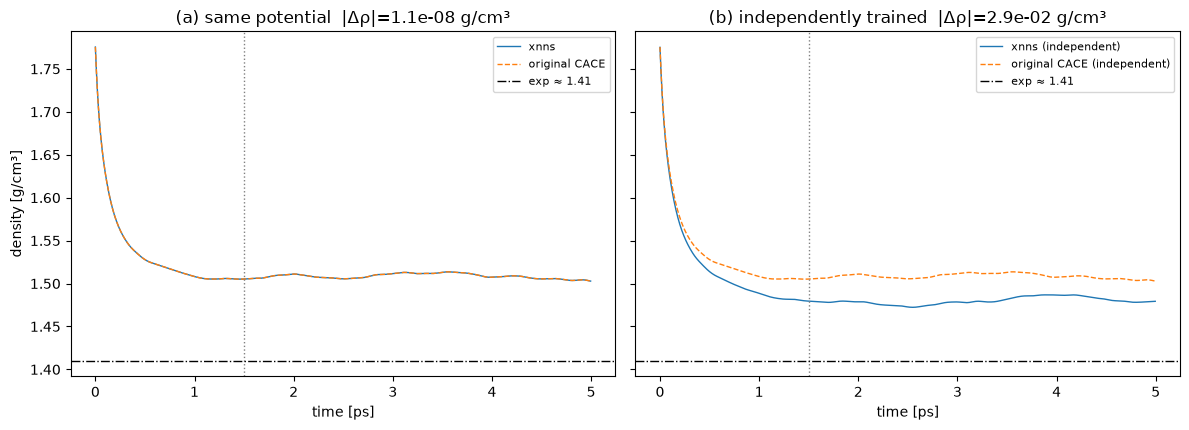

                            xnn   original CACE      |diff|
------------------------------------------------------------
(a) same PES              1.5085          1.5085     1.1e-08
(b) independent           1.4798          1.5085     2.9e-02
experiment                  1.41


In [8]:
t_ps = np.arange(N_EQUIL + N_PROD) * (DT / u.fs) / 1000.0
xc = N_EQUIL * (DT / u.fs) / 1000.0
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
ax[0].plot(t_ps, rho_xa, label="xnn", lw=1)
ax[0].plot(t_ps, rho_ua, label="original CACE", lw=1, ls="--")
ax[0].set_title(f"(a) same potential  |Δρ|={abs(da_x-da_u):.1e} g/cm³")
ax[1].plot(t_ps, rho_xb, label="xnn (independent)", lw=1)
ax[1].plot(t_ps, rho_ub, label="original CACE (independent)", lw=1, ls="--")
ax[1].set_title(f"(b) independently trained  |Δρ|={abs(db_x-db_u):.1e} g/cm³")
for a in ax:
    a.axvline(xc, color="gray", ls=":", lw=1)
    a.axhline(RHO_EXP, color="k", ls="-.", lw=1, label=f"exp ≈ {RHO_EXP}")
    a.set_xlabel("time [ps]"); a.legend(fontsize=8)
ax[0].set_ylabel("density [g/cm³]")
plt.tight_layout(); plt.savefig("argon_density_md.png", dpi=120); plt.show()

print(f"{'':<20}{'xnn':>12}{'original CACE':>16}{'|diff|':>12}")
print("-" * 60)
print(f"{'(a) same PES':<20}{da_x:>12.4f}{da_u:>16.4f}{abs(da_x-da_u):>12.1e}")
print(f"{'(b) independent':<20}{db_x:>12.4f}{db_u:>16.4f}{abs(db_x-db_u):>12.1e}")
print(f"{'experiment':<20}{RHO_EXP:>12.2f}")

## Summary

* **Track (a)**: copying the trained original-CACE weights into `xnn` gives
  identical energy/forces/stress and **identical NPT densities**; the `xnn`
  inference/MD path reproduces the original CACE exactly.
* **Track (b)**: an independently trained `xnn` CACE lands within the thermal
  fluctuations of the original, both near the experimental liquid-Ar density
  (~1.41 g/cm³).

Same conclusions, same pipeline, fourth model family: CACE joins MACE, NequIP
and Allegro as a faithful member of the xnn GNN family (shared `GNNPotential`
base, featurizers, `ForceStressOutput`, ASE deploy), and the only one that
needs no e3nn.